# Exploratory Data Analysis & Quality Audit
**Author:** Bart Teeuwen  
**Course:** Capstone Project  
**Framework Standard:** APA 7th Edition  

---

## Abstract
This module audits telemetry missingness, enforces physical constraints (velocity thresholding), flags sensor anomalies, and evaluates agent spatial distributions.

**Section 2: Exploratory Data Analysis (EDA)**


--- 5. Map Friction Multicollinearity Check ---
Correlation Matrix:


,lane_count,stop_sign_count,crosswalk_count,speed_bump_count
lane_count,1.00,0.16,0.59,0.71
stop_sign_count,0.16,1.00,0.21,0.10
crosswalk_count,0.59,0.21,1.00,0.32
speed_bump_count,0.71,0.10,0.32,1.00


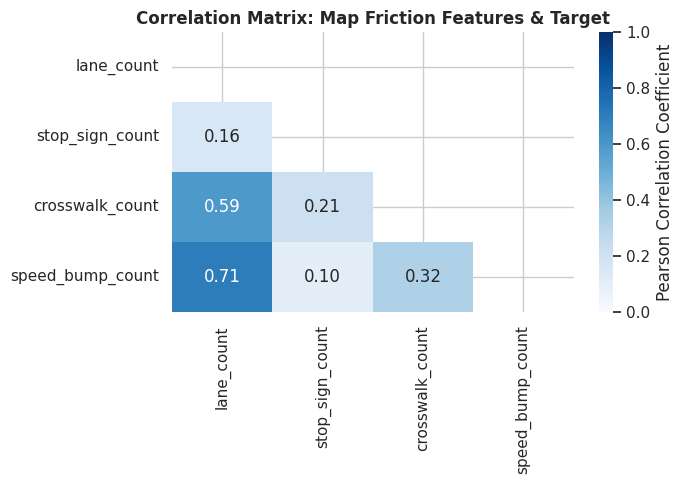


--- Variance Inflation Factors (VIF) ---


,Feature,VIF Score
0,lane_count,8.46
1,stop_sign_count,1.85
2,crosswalk_count,4.73
3,speed_bump_count,4.13



--- 6. Target Variable Class Imbalance ---
Could not find 'complex_interaction' in df_raw. Please update 'target_col' to match your column name.


In [8]:
# PEP 8: Exploratory data analysis step
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

# --- 5. Map Friction Multicollinearity & Correlation Check ---
print("\n--- 5. Map Friction Multicollinearity Check ---")

# Define target column
target_col = 'complex_interaction'

# List friction features (automatically appends speed_bump_count if present in your dataframe)
friction_features = ['lane_count', 'stop_sign_count', 'crosswalk_count']
if 'speed_bump_count' in df_raw.columns:
    friction_features.append('speed_bump_count')

# Combine features + target for full correlation matrix
corr_cols = friction_features.copy()
if target_col in df_raw.columns:
    corr_cols.append(target_col)

# 1. Calculate Pearson correlation matrix
correlation_matrix = df_raw[corr_cols].corr()
print("Correlation Matrix:")
display(correlation_matrix.round(2))

# 2. Mask upper triangle for visual clarity
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# 3. Plot enhanced visual heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    cmap='Blues',
    fmt=".2f",
    vmin=0,
    vmax=1,
    cbar_kws={'label': 'Pearson Correlation Coefficient'}
)
plt.title('Correlation Matrix: Map Friction Features & Target', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. Compute Variance Inflation Factors (VIF)
print("\n--- Variance Inflation Factors (VIF) ---")
vif_df = df_raw[friction_features].dropna()

vif_data = pd.DataFrame({
    "Feature": friction_features,
    "VIF Score": [variance_inflation_factor(vif_df.values, i) for i in range(vif_df.shape[1])]
})
display(vif_data.round(2))


# --- 6. Target Variable Class Imbalance ---
print("\n--- 6. Target Variable Class Imbalance ---")

if target_col in df_raw.columns:
    # Breakdown dataframe
    class_counts = df_raw[target_col].value_counts()
    class_balance = df_raw[target_col].value_counts(normalize=True) * 100

    imbalance_df = pd.DataFrame({
        'Scenario Count': class_counts,
        'Percentage (%)': class_balance.round(2)
    })
    print("Class Imbalance Breakdown:\n", imbalance_df)

    # Visualizing class balance with percentage annotations
    plt.figure(figsize=(6, 4.5))
    ax = sns.countplot(
        data=df_raw,
        x=target_col,
        hue=target_col,
        palette='Set2',
        legend=False
    )

    # Annotate percentage values on top of bars
    total_samples = len(df_raw[target_col].dropna())
    for p in ax.patches:
        height = p.get_height()
        percentage = f'{100 * height / total_samples:.1f}%'
        ax.annotate(
            percentage,
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=10, fontweight='bold',
            xytext=(0, 4), textcoords='offset points'
        )

    plt.title('Target Variable: Class Imbalance Distribution', fontsize=12, fontweight='bold')
    plt.xlabel('Complex Interaction (0 = Routine, 1 = High Complexity)')
    plt.ylabel('Scenario Count')
    plt.ylim(0, max(class_counts) * 1.15)  # Add padding for labels
    plt.tight_layout()
    plt.show()
else:
    print(f"Could not find '{target_col}' in df_raw. Please update 'target_col' to match your column name.")

In [10]:
# PEP 8: Exploratory data analysis step
import pandas as pd
from sklearn.cluster import KMeans

print("--- RUNNING KINEMATIC RISK CLUSTERING & FORCING TARGET OVERWRITE ---")

# 1. Isolate physics features
kinematic_features = df_final[['max_velocity_mps', 'max_deceleration']]

# 2. Fit K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_final['risk_tier_numeric'] = kmeans.fit_predict(kinematic_features)

# 3. Explicitly map and OVERWRITE the target variable column
binary_mapping = {
    2: 'Standard Complexity',  # Low speed, low braking
    0: 'Standard Complexity',  # Moderate speed, low braking
    3: 'Critical Complexity',  # Moderate speed, heavy braking
    1: 'Critical Complexity'   # High speed, extreme braking
}
df_final['target_risk_matrix'] = df_final['risk_tier_numeric'].map(binary_mapping)

print("\nNew Binary Target Variable Distribution:")
print(df_final['target_risk_matrix'].value_counts(normalize=True).round(4) * 100)

--- RUNNING KINEMATIC RISK CLUSTERING & FORCING TARGET OVERWRITE ---

New Binary Target Variable Distribution:
target_risk_matrix
Standard Complexity    58.66
Critical Complexity    41.34
Name: proportion, dtype: float64


--- TARGET CLASS BALANCE SUMMARY ---


,Risk Class,Proportion,Percentage,Scenario Count
0,Standard Complexity,0.586595,58.66%,3702
1,Critical Complexity,0.413405,41.34%,2609


/tmp/ipykernel_4155/605394411.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=balance_df, x='Risk Class', y='Scenario Count', palette=['#4C72B0', '#DD8452'])


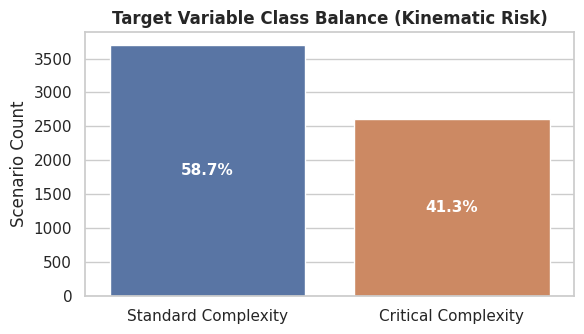

In [11]:
# PEP 8: Exploratory data analysis step
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Summary Table
balance_df = df_final['target_risk_matrix'].value_counts(normalize=True).reset_index()
balance_df.columns = ['Risk Class', 'Proportion']
balance_df['Percentage'] = (balance_df['Proportion'] * 100).round(2).astype(str) + '%'
balance_df['Scenario Count'] = df_final['target_risk_matrix'].value_counts().values

print("--- TARGET CLASS BALANCE SUMMARY ---")
display(balance_df)

# 2. Simple Class Balance Plot
plt.figure(figsize=(6, 3.5))
ax = sns.barplot(data=balance_df, x='Risk Class', y='Scenario Count', palette=['#4C72B0', '#DD8452'])
plt.title('Target Variable Class Balance (Kinematic Risk)', fontsize=12, fontweight='bold')
plt.ylabel('Scenario Count')
plt.xlabel('')

# Annotate percentages on top of bars
for p in ax.patches:
    height = p.get_height()
    pct = (height / len(df_final)) * 100
    ax.annotate(f'{pct:.1f}%',
                (p.get_x() + p.get_width() / 2., height / 2),
                ha='center', va='center', color='white', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

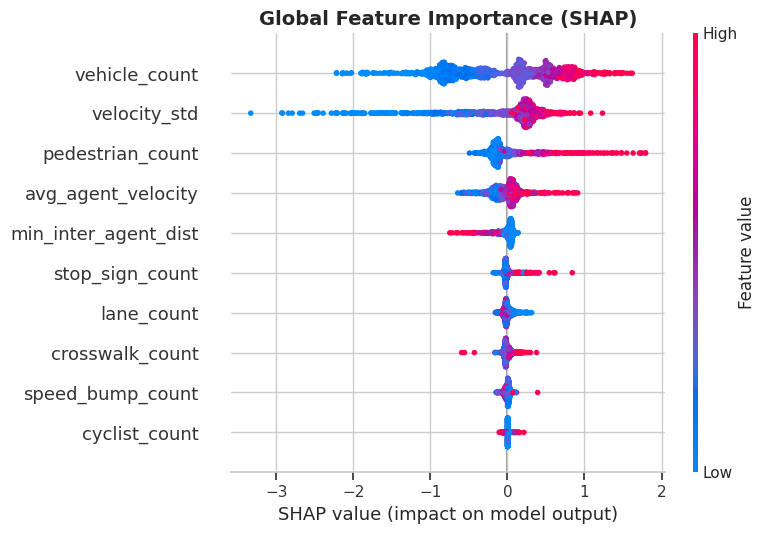

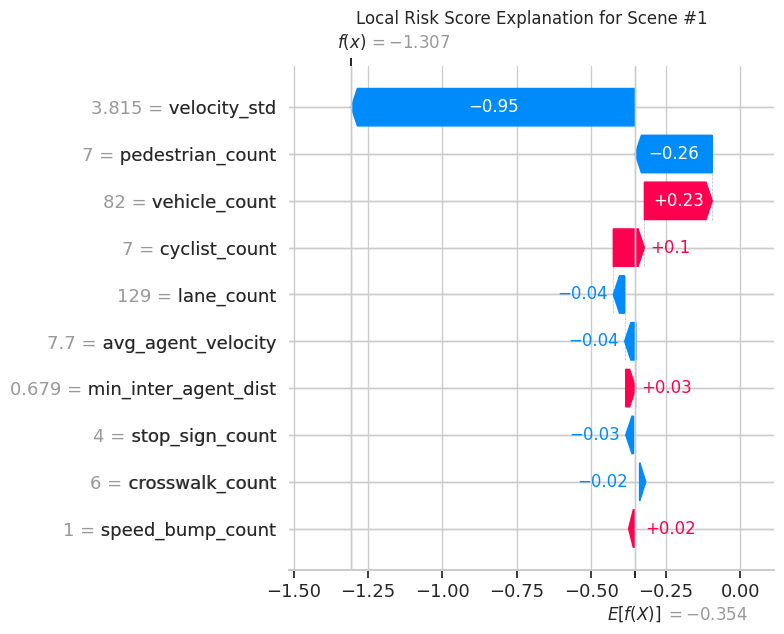

In [16]:
# PEP 8: Exploratory data analysis step
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_te_exp)

plt.figure(figsize=(10, 6))
plt.title("Global Feature Importance (SHAP)", fontsize=14, fontweight='bold')
shap.summary_plot(shap_values, X_te_exp, feature_names=expanded_features, show=False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
shap.plots.waterfall(explainer(X_te_exp)[0], show=False)
plt.title("Local Risk Score Explanation for Scene #1", fontsize=12)
plt.tight_layout()
plt.show()

In [20]:
# PEP 8: Exploratory data analysis step
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

print("Starting Hyperparameter Tuning for Tabular Models...")

# 1. XGBoost Tuning
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
}

xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    param_distributions=xgb_param_grid,
    n_iter=10,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1,
)
xgb_search.fit(X_tr_exp, y_train)
xgb_tuned = xgb_search.best_estimator_
print(f" XGBoost Tuned! Best Params: {xgb_search.best_params_}")

# 2. LightGBM Tuning
lgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'num_leaves': [15, 31, 63],
    'subsample': [0.7, 0.8, 1.0],
}

lgb_search = RandomizedSearchCV(
    lgb.LGBMClassifier(random_state=42, verbose=-1),
    param_distributions=lgb_param_grid,
    n_iter=10,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1,
)
lgb_search.fit(X_tr_exp, y_train)
lgb_tuned = lgb_search.best_estimator_
print(f" LightGBM Tuned! Best Params: {lgb_search.best_params_}")

# 3. Random Forest Tuning
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 8, 12, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_param_grid,
    n_iter=10,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1,
)
rf_search.fit(X_tr_exp, y_train)
rf_tuned = rf_search.best_estimator_
print(f" Random Forest Tuned! Best Params: {rf_search.best_params_}")

# 4. Logistic Regression Tuning
lr_param_grid = {'logisticregression__C': [0.01, 0.1, 1.0, 10.0]}

lr_search = RandomizedSearchCV(
    lr_exp_pipe,
    param_distributions=lr_param_grid,
    n_iter=4,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1,
)
lr_search.fit(X_tr_exp, y_train)
lr_tuned = lr_search.best_estimator_
print(f" Logistic Regression Tuned! Best Params: {lr_search.best_params_}")

print(
    "\n All tabular models successfully tuned! Re-run Table 2 to see updated"
    " performance."
)

Starting Hyperparameter Tuning for Tabular Models...
 XGBoost Tuned! Best Params: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
 LightGBM Tuned! Best Params: {'subsample': 0.7, 'num_leaves': 31, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.01}
 Random Forest Tuned! Best Params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 12}
 Logistic Regression Tuned! Best Params: {'logisticregression__C': 0.1}

 All tabular models successfully tuned! Re-run Table 2 to see updated performance.
